In [28]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

Load Dataset

In [29]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

Preprocess Data

In [30]:
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

In [31]:
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

Improved Neural Network Architecture

In [32]:
model = keras.Sequential([

    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])

Compile Model

In [33]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Train Model

In [34]:
history = model.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8105 - loss: 0.6020 - val_accuracy: 0.9595 - val_loss: 0.1402
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9459 - loss: 0.1779 - val_accuracy: 0.9672 - val_loss: 0.1091
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9601 - loss: 0.1325 - val_accuracy: 0.9710 - val_loss: 0.0974
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9658 - loss: 0.1126 - val_accuracy: 0.9734 - val_loss: 0.0902
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9694 - loss: 0.1014 - val_accuracy: 0.9737 - val_loss: 0.0876
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9738 - loss: 0.0863 - val_accuracy: 0.9773 - val_loss: 0.0791
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9773 - loss: 0.0782 - val_accuracy: 0.9758 - val_loss: 0.0833
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9769 - loss: 0

Evaluate Model

In [35]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9776 - loss: 0.0936
Test Accuracy: 0.9814000129699707


Plot Training Performance

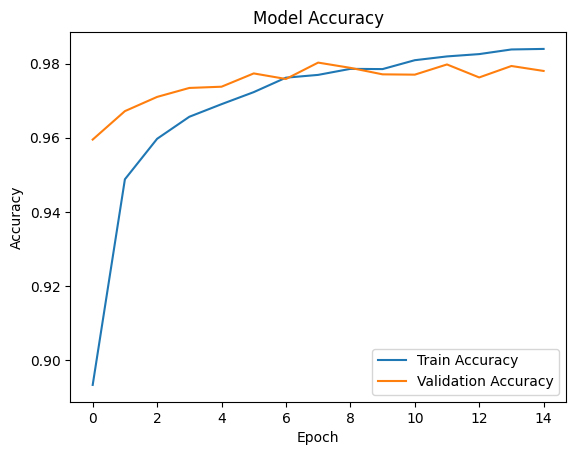

In [36]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model Accuracy")
plt.show()

Loss Plot

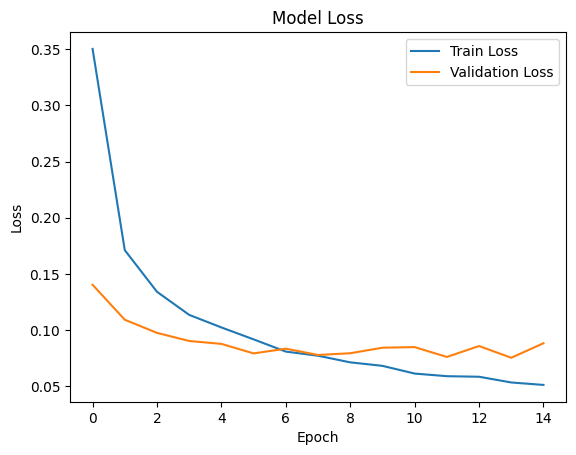

In [37]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Model Loss")
plt.show()